# XGBoost — N-CMAPSS DS01 / Fc = 3

Metodología de pre procesamiento, entrenamiento y predicción:
1. Carga y filtrado (Fc=3, sin `hs`)
2. Feature engineering: `pos_relativa` + rolling join inter-ciclo
3. Split temporal por unidad (motor entero a train o test)
4. Entrenamiento XGBoost con early stopping
5. Predicción por observación individual → agregación por ciclo (media / mediana)
6. Evaluación: RMSE, MAE, R², Score NASA (penaliza predicciones tardías)
7. Análisis de incertidumbre: `RUL_std` por ciclo
8. Importancia de features (gain)

**Clave diferencial:** el modelo predice RUL en cada lectura individual; la predicción  
definitiva por ciclo surge de agregar (mediana) de las predicciones individuales.


In [ ]:
# CELDA 0 — INSTALACIÓN (descomentar si es necesario)
# !pip install xgboost optuna shap scikit-learn h5py numpy pandas matplotlib seaborn

In [3]:
# CELDA 1 — IMPORTS Y CONSTANTES GLOBALES

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
from scipy import stats as sp_stats

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

# ── Constantes globales
FILE_PATH = 'N-CMAPSS_DS01-005.h5'
FC        = 3          # clase de vuelo analizada
SEED      = 42
np.random.seed(SEED)

print(" Imports OK")
print(f"   XGBoost : {xgb.__version__}")
print(f"   Optuna  : {optuna.__version__}")
print(f"   Filtro  : Fc = {FC}  |  sin 'hs'")


 Imports OK
   XGBoost : 3.2.0
   Optuna  : 4.6.0
   Filtro  : Fc = 3  |  sin 'hs'


CELDA 2 — CARGA, FILTRADO (Fc=3) Y EXCLUSIÓN DE hs

Cargamos el archivo HDF5 y aplicamos el filtro global Fc=3.
La variable 'hs' se excluye porque no es observable en un motor real.

In [4]:
print("=" * 60)
print("CELDA 2 — CARGA Y FILTRADO")
print("=" * 60)

with h5py.File(FILE_PATH, 'r') as f:
    W_dev    = np.array(f['W_dev'])
    X_s_dev  = np.array(f['X_s_dev'])
    Y_dev    = np.array(f['Y_dev'])
    A_dev    = np.array(f['A_dev'])
    W_test   = np.array(f['W_test'])
    X_s_test = np.array(f['X_s_test'])
    Y_test   = np.array(f['Y_test'])
    A_test   = np.array(f['A_test'])
    W_var    = [v.decode() for v in f['W_var'][:]]
    Xs_var   = [v.decode() for v in f['X_s_var'][:]]
    A_var    = [v.decode() for v in f['A_var'][:]]

# Excluir 'hs' del array A
hs_idx    = A_var.index('hs') if 'hs' in A_var else None
A_var_use = [v for v in A_var if v != 'hs']
A_dev_use  = np.delete(A_dev,  hs_idx, axis=1) if hs_idx is not None else A_dev
A_test_use = np.delete(A_test, hs_idx, axis=1) if hs_idx is not None else A_test

all_cols = A_var_use + W_var + Xs_var + ['RUL']

df_dev_full = pd.DataFrame(
    np.hstack([A_dev_use, W_dev, X_s_dev, Y_dev.reshape(-1, 1)]),
    columns=all_cols)
df_test_full = pd.DataFrame(
    np.hstack([A_test_use, W_test, X_s_test, Y_test.reshape(-1, 1)]),
    columns=all_cols)

for col in ['unit', 'cycle', 'Fc']:
    df_dev_full[col]  = df_dev_full[col].astype(int)
    df_test_full[col] = df_test_full[col].astype(int)

# Filtro global Fc=3
df_dev_fc3  = df_dev_full[ df_dev_full['Fc']  == FC].copy().sort_values(['unit','cycle']).reset_index(drop=True)
df_test_fc3 = df_test_full[df_test_full['Fc'] == FC].copy().sort_values(['unit','cycle']).reset_index(drop=True)

# Resumen
units_dev  = sorted(df_dev_fc3['unit'].unique())
units_test = sorted(df_test_fc3['unit'].unique())
print(f"\n  Unidades desarrollo : {units_dev}")
print(f"  Unidades test       : {units_test}")
print(f"\n  Dev  — filas: {len(df_dev_fc3):>8,}  |  ciclos únicos: {df_dev_fc3['cycle'].nunique()}")
print(f"  Test — filas: {len(df_test_fc3):>8,}  |  ciclos únicos: {df_test_fc3['cycle'].nunique()}")

for u in units_dev:
    df_u  = df_dev_fc3[df_dev_fc3['unit'] == u]
    n_cyc = df_u['cycle'].nunique()
    obs_c = len(df_u) // n_cyc
    rul_r = (df_u['RUL'].max(), df_u['RUL'].min())
    print(f"  Unit {u}: {n_cyc} ciclos  ~{obs_c} obs/ciclo  RUL [{rul_r[1]:.0f}–{rul_r[0]:.0f}]")


CELDA 2 — CARGA Y FILTRADO

  Unidades desarrollo : [2, 5]
  Unidades test       : [10]

  Dev  — filas: 2,329,235  |  ciclos únicos: 89
  Test — filas: 1,190,670  |  ciclos únicos: 82
  Unit 2: 75 ciclos  ~13987 obs/ciclo  RUL [0–74]
  Unit 5: 89 ciclos  ~14383 obs/ciclo  RUL [0–88]


In [ ]:
# CELDA 3 — FEATURE ENGINEERING

# Implementamos los tres bloques de la arquitectura predecir-luego-agregar:
#
#   [A] pos_relativa : posición normalizada [0,1] dentro del ciclo.
#       Permite al modelo distinguir despegue (≈0) de crucero (≈0.5)
#       y descenso (≈1) cuando el valor crudo del sensor es similar.
#
#   [B] Rolling inter-ciclo : tendencia acumulada de degradación entre ciclos.
#       Se calcula sobre la media de cada ciclo y se une a cada observación
#       individual mediante merge (join). Ventanas de 5 y 10 ciclos.
#       Slope lineal sobre ventana de 10 ciclos.
#
#   [C] Estadísticos intra-ciclo (max, std del ciclo actual):
#       Captura el comportamiento bajo máxima demanda y la estabilidad
#       del sensor dentro del vuelo actual.


def build_features(df, sensor_cols, windows=(5, 10), slope_w=10, fit_scaler=None):
    """
    Construye todas las features para la arquitectura predecir-luego-agregar.
    Parámetros
    ----------
    df          : DataFrame con columnas unit, cycle, sensor_cols, RUL
    sensor_cols : lista de sensores a procesar
    windows     : ventanas para rolling inter-ciclo
    slope_w     : ventana para slope lineal
    fit_scaler  : None → crea y ajusta un nuevo StandardScaler
                  objeto  → transforma con scaler ya ajustado
    Devuelve
    --------
    df_out      : DataFrame con todas las features añadidas
    feature_names : lista de nombres de features de entrada al modelo
    scaler      : objeto StandardScaler ajustado
    """
    df = df.copy().sort_values(['unit', 'cycle']).reset_index(drop=True)

    # ── [A] Posición intra-vuelo 
    df['pos_intra']    = df.groupby(['unit','cycle']).cumcount()
    df['pos_relativa'] = (df['pos_intra'] /
                          df.groupby(['unit','cycle'])['pos_intra'].transform('max')
                          .replace(0, 1))   # evitar div/0 en ciclos de 1 obs

    # ── [B] Rolling inter-ciclo (sobre media por ciclo) 
    ciclo_means = (df.groupby(['unit','cycle'])[sensor_cols]
                   .mean().reset_index()
                   .sort_values(['unit','cycle']))

    roll_cols = []
    for w in windows:
        for col in sensor_cols:
            cname = f'{col}_roll{w}_mean'
            ciclo_means[cname] = (ciclo_means.groupby('unit')[col]
                                  .transform(lambda x: x.rolling(w, min_periods=1).mean()))
            roll_cols.append(cname)
            cname2 = f'{col}_roll{w}_std'
            ciclo_means[cname2] = (ciclo_means.groupby('unit')[col]
                                   .transform(lambda x: x.rolling(w, min_periods=1)
                                              .std().fillna(0)))
            roll_cols.append(cname2)

    # Slope inter-ciclo
    def rolling_slope(series, w=slope_w):
        result = np.zeros(len(series))
        arr    = series.values
        for i in range(len(arr)):
            seg = arr[max(0, i - w + 1): i + 1]
            if len(seg) >= 2:
                result[i] = np.polyfit(np.arange(len(seg)), seg, 1)[0]
        return pd.Series(result, index=series.index)

    for col in sensor_cols:
        cname = f'{col}_slope{slope_w}'
        ciclo_means[cname] = (ciclo_means.groupby('unit')[col]
                              .transform(lambda x: rolling_slope(x, slope_w)))
        roll_cols.append(cname)

    # Merge rolling features → observaciones individuales
    df = df.merge(ciclo_means[['unit','cycle'] + roll_cols],
                  on=['unit','cycle'], how='left')

    # ── [C] Estadísticos intra-ciclo (contexto del vuelo actual) 
    for col in sensor_cols:
        df[f'{col}_cyc_max'] = (df.groupby(['unit','cycle'])[col]
                                .transform('max'))
        df[f'{col}_cyc_std'] = (df.groupby(['unit','cycle'])[col]
                                .transform('std').fillna(0))

    intra_cols = [f'{c}_cyc_max' for c in sensor_cols] + [f'{c}_cyc_std' for c in sensor_cols]

    # ── Cycle_norm : posición relativa del ciclo en la vida del motor
    for u in df['unit'].unique():
        mask = df['unit'] == u
        cycs = df.loc[mask, 'cycle']
        df.loc[mask, 'cycle_norm'] = ((cycs - cycs.min()) /
                                       (cycs.max() - cycs.min() + 1e-9))

    # ── Lista final de features 
    base_features   = sensor_cols + W_var + ['pos_relativa', 'cycle_norm']
    feature_names   = base_features + roll_cols + intra_cols

    # ── Escalado (opcional para XGBoost, pero útil si se añade meta-modelo)
    X = df[feature_names].values
    if fit_scaler is None:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    else:
        scaler = fit_scaler
        X = scaler.transform(X)

    df_out = df.copy()
    df_out[feature_names] = X

    return df_out, feature_names, scaler


# Construir features para desarrollo y test
print("Construyendo features de desarrollo...")
t0 = time.time()
df_dev_fe, FEATURE_NAMES, scaler = build_features(df_dev_fc3, Xs_var)
print(f"  OK ({time.time()-t0:.1f}s)  |  {len(FEATURE_NAMES)} features por observación")

print("Construyendo features de test (scaler ajustado en dev)...")
t0 = time.time()
df_test_fe, _, _ = build_features(df_test_fc3, Xs_var, fit_scaler=scaler)
print(f"  OK ({time.time()-t0:.1f}s)")

print(f"\n  Desglose de features:")
print(f"    Raw sensores + W + pos + cycle_norm : {len(Xs_var) + len(W_var) + 2}")
print(f"    Rolling mean/std (v5, v10)          : {len(Xs_var) * 2 * 2}")
print(f"    Slope inter-ciclo (v10)             : {len(Xs_var)}")
print(f"    Estadísticos intra-ciclo (max, std) : {len(Xs_var) * 2}")
print(f"    TOTAL                               : {len(FEATURE_NAMES)}")


Construyendo features de desarrollo...
  OK (18.8s)  |  118 features por observación
Construyendo features de test (scaler ajustado en dev)...
  OK (5.7s)

  Desglose de features:
    Raw sensores + W + pos + cycle_norm : 20
    Rolling mean/std (v5, v10)          : 56
    Slope inter-ciclo (v10)             : 14
    Estadísticos intra-ciclo (max, std) : 28
    TOTAL                               : 118


 Split por unidad completado
   Train — unidades: [2]  |  obs: 1,049,088  |  ciclos: 75
   Val   — unidades: [5]      |  obs: 1,280,147  |  ciclos: 89
   Test  — unidades: [10]   |  obs: 1,190,670  |  ciclos: 82


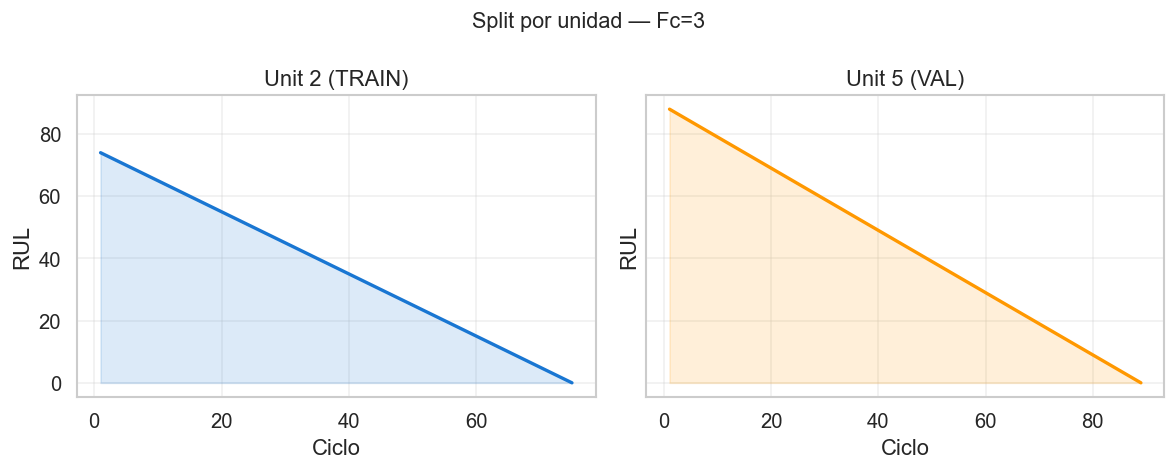

In [6]:
# CELDA 4 — SPLIT POR UNIDAD (GroupKFold temporal)

# Las observaciones del mismo ciclo están autocorrelacionadas, por lo que
# el split NUNCA puede ser aleatorio por fila. Debe ser por ciclo completo:
# todos los ciclos de una unidad van a train o a val, nunca mezclados.
#
# Con pocas unidades Fc=3 usamos leave-one-unit-out: la última unidad
# (mayor índice) va a validación durante el entrenamiento.
# El conjunto test es el proporcionado por el dataset (df_test_fc3).


units_sorted = sorted(df_dev_fe['unit'].unique())
val_unit     = [units_sorted[-1]]    # última unidad para validación
train_units  = units_sorted[:-1]

mask_train = df_dev_fe['unit'].isin(train_units)
mask_val   = df_dev_fe['unit'].isin(val_unit)

X_train = df_dev_fe.loc[mask_train, FEATURE_NAMES].values
y_train = df_dev_fe.loc[mask_train, 'RUL'].values

X_val   = df_dev_fe.loc[mask_val, FEATURE_NAMES].values
y_val   = df_dev_fe.loc[mask_val, 'RUL'].values

X_test  = df_test_fe[FEATURE_NAMES].values
y_test  = df_test_fe['RUL'].values

print(" Split por unidad completado")
print(f"   Train — unidades: {train_units}  |  obs: {len(X_train):,}  |  ciclos: {df_dev_fe.loc[mask_train,'cycle'].nunique()}")
print(f"   Val   — unidades: {val_unit}      |  obs: {len(X_val):,}  |  ciclos: {df_dev_fe.loc[mask_val,'cycle'].nunique()}")
print(f"   Test  — unidades: {units_test}   |  obs: {len(X_test):,}  |  ciclos: {df_test_fe['cycle'].nunique()}")

# Visualización del split
fig, axes = plt.subplots(1, len(units_sorted), figsize=(5*len(units_sorted), 4), sharey=True)
fig.suptitle(f'Split por unidad — Fc={FC}', fontsize=13)
if len(units_sorted) == 1:
    axes = [axes]
colors_split = {u: ('#1976D2' if u in train_units else '#FF9800') for u in units_sorted}
for ax, u in zip(axes, units_sorted):
    df_u = df_dev_fe[df_dev_fe['unit'] == u].groupby('cycle')['RUL'].mean()
    ax.plot(df_u.index, df_u.values, color=colors_split[u], lw=2)
    ax.fill_between(df_u.index, df_u.values, alpha=0.15, color=colors_split[u])
    split_label = 'TRAIN' if u in train_units else 'VAL'
    ax.set_title(f'Unit {u} ({split_label})')
    ax.set_xlabel('Ciclo')
    ax.set_ylabel('RUL')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# CELDA 5 — BASELINE + OPTIMIZACIÓN CON OPTUNA

# Primero un baseline con parámetros razonables para tener una referencia.
# Luego Optuna (50 trials) busca los hiperparámetros óptimos.

# IMPORTANTE: la métrica de validación se calcula sobre las predicciones
# AGREGADAS por ciclo (mediana), no sobre observaciones individuales.
# Esto alinea la optimización con el objetivo real.


def rmse_por_ciclo(model, X, df_ref, agg='median'):
    """Predice obs individuales, agrega por ciclo y calcula RMSE."""
    preds = model.predict(X)
    df_tmp = df_ref[['unit','cycle','RUL']].copy()
    df_tmp['pred'] = preds
    ciclo_p = df_tmp.groupby(['unit','cycle']).agg(
        RUL_real=('RUL','first'),
        RUL_agg =('pred', agg)
    ).reset_index()
    return mean_squared_error(ciclo_p['RUL_real'], ciclo_p['RUL_agg']) ** 0.5

# 5.1 Baseline
print("[5.1] Entrenando baseline...")
baseline = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, reg_alpha=0.1,
    random_state=SEED, n_jobs=-1, verbosity=0,
    eval_metric='rmse', early_stopping_rounds=30
)
baseline.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
rmse_base = rmse_por_ciclo(baseline, X_val, df_dev_fe[mask_val])
print(f"   Baseline Val RMSE (ciclo, mediana): {rmse_base:.4f}")

# 5.2 Optuna
print("\n[5.2] Optimizando con Optuna (50 trials)...")
t0 = time.time()

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 3, 9),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma'            : trial.suggest_float('gamma', 0.0, 5.0),
        'random_state'     : SEED, 'n_jobs': -1, 'verbosity': 0,
        'eval_metric'      : 'rmse', 'early_stopping_rounds': 30,
    }
    m = xgb.XGBRegressor(**params)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return rmse_por_ciclo(m, X_val, df_dev_fe[mask_val])

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n   Completado en {time.time()-t0:.1f}s")
print(f"   Mejor RMSE val (ciclo, mediana): {study.best_value:.4f}")
print("   Mejores parámetros:")
for k, v in study.best_params.items():
    print(f"     {k:22s}: {v}")


[5.1] Entrenando baseline...
   Baseline Val RMSE (ciclo, mediana): 10.1676

[5.2] Optimizando con Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


   Completado en 3401.1s
   Mejor RMSE val (ciclo, mediana): 7.7274
   Mejores parámetros:
     n_estimators          : 580
     max_depth             : 4
     learning_rate         : 0.15792004331818402
     subsample             : 0.8344982514396176
     colsample_bytree      : 0.9953354208429003
     min_child_weight      : 18
     reg_alpha             : 0.007785548853701786
     reg_lambda            : 0.31908141217447467
     gamma                 : 0.7991314327318505


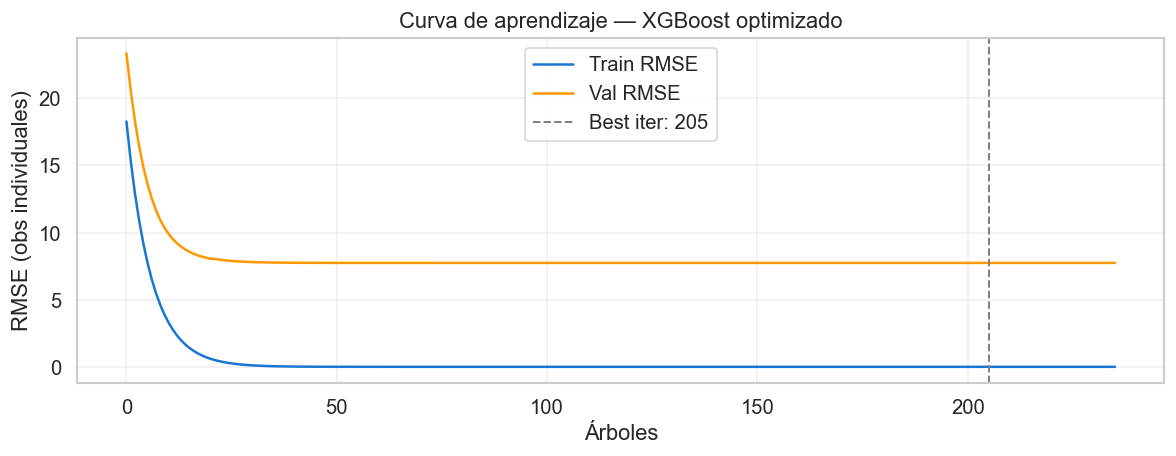

  → Figura guardada: xgb2_02_learning_curve.png


In [ ]:
# CELDA 6 — MODELO FINAL

best_p = study.best_params.copy()
best_p.update({'random_state': SEED, 'n_jobs': -1, 'verbosity': 0,
               'eval_metric': 'rmse', 'early_stopping_rounds': 30})

model = xgb.XGBRegressor(**best_p)
model.fit(X_train, y_train,
          eval_set=[(X_train, y_train), (X_val, y_val)],
          verbose=False)

# Curva de aprendizaje
res = model.evals_result()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(res['validation_0']['rmse'], label='Train RMSE', color='#1976D2', lw=1.5)
ax.plot(res['validation_1']['rmse'], label='Val RMSE',   color='#FF9800', lw=1.5)
ax.axvline(model.best_iteration, color='gray', ls='--', lw=1.2,
           label=f'Best iter: {model.best_iteration}')
ax.set_xlabel('Árboles')
ax.set_ylabel('RMSE (obs individuales)')
ax.set_title('Curva de aprendizaje — XGBoost optimizado')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('xgb2_02_learning_curve.png')
plt.show()
print("  → Figura guardada: xgb2_02_learning_curve.png")


In [ ]:
# CELDA 7 — PREDICCIÓN → AGREGACIÓN → EVALUACIÓN

# Paso clave de la arquitectura: el modelo predice un RUL por cada lectura
# individual. Después agrupamos por ciclo y calculamos la predicción
# definitiva como mediana (robusta a outliers de despegue/aterrizaje).
#
# La columna RUL_std da la incertidumbre de cada ciclo:
# alta dispersión intra-ciclo = motor en zona de degradación inestable.
#
# Score NASA (S): métrica asimétrica que penaliza más las predicciones
# tardías (RUL predicho > real) que las adelantadas, porque en mantenimiento
# predecir "aún le queda vida" cuando ya está fallando es más peligroso.
#   S = Σ exp(d/10) - 1  si d > 0  (tarde)
#   S = Σ exp(-d/13) - 1 si d ≤ 0  (adelantado)


def nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    return float(np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)))

def aggregate_predictions(model, X, df_ref, label=''):
    """Predice obs individuales, agrega por ciclo y evalúa."""
    preds = model.predict(X)
    df_tmp = df_ref[['unit','cycle','RUL']].copy().reset_index(drop=True)
    df_tmp['RUL_pred_obs'] = preds

    ciclo_p = df_tmp.groupby(['unit','cycle']).agg(
        RUL_real   = ('RUL',         'first'),
        RUL_media  = ('RUL_pred_obs', 'mean'),
        RUL_mediana= ('RUL_pred_obs', 'median'),
        RUL_p25    = ('RUL_pred_obs', lambda x: x.quantile(0.25)),
        RUL_p75    = ('RUL_pred_obs', lambda x: x.quantile(0.75)),
        RUL_std    = ('RUL_pred_obs', 'std'),
        n_obs      = ('RUL_pred_obs', 'count'),
    ).reset_index()

    print(f"\n{'─'*56}")
    print(f"  {label}")
    print(f"{'─'*56}")
    for agg_col, agg_label in [('RUL_mediana','Mediana'), ('RUL_media','Media')]:
        rmse = mean_squared_error(ciclo_p['RUL_real'], ciclo_p[agg_col]) ** 0.5
        mae  = mean_absolute_error(ciclo_p['RUL_real'], ciclo_p[agg_col])
        r2   = r2_score(ciclo_p['RUL_real'], ciclo_p[agg_col])
        s    = nasa_score(ciclo_p['RUL_real'], ciclo_p[agg_col])
        print(f"  [{agg_label:7s}]  RMSE={rmse:7.3f}  MAE={mae:7.3f}  "
              f"R²={r2:.4f}  S={s:.1f}")
    return ciclo_p, df_tmp

print("=" * 56)
print("  MÉTRICAS — Arquitectura Predecir → Agregar")
print("=" * 56)
ciclo_train, obs_train = aggregate_predictions(
    model, X_train, df_dev_fe[mask_train].reset_index(drop=True), 'TRAIN')
ciclo_val, obs_val = aggregate_predictions(
    model, X_val, df_dev_fe[mask_val].reset_index(drop=True), 'VALIDACIÓN')
ciclo_test, obs_test = aggregate_predictions(
    model, X_test, df_test_fe.reset_index(drop=True), 'TEST')
print(f"{'─'*56}")

  MÉTRICAS — Arquitectura Predecir → Agregar

────────────────────────────────────────────────────────
  TRAIN
────────────────────────────────────────────────────────
  [Mediana]  RMSE=  0.003  MAE=  0.002  R²=1.0000  S=0.0
  [Media  ]  RMSE=  0.003  MAE=  0.002  R²=1.0000  S=0.0

────────────────────────────────────────────────────────
  VALIDACIÓN
────────────────────────────────────────────────────────
  [Mediana]  RMSE=  7.727  MAE=  6.533  R²=0.9095  S=65.7
  [Media  ]  RMSE=  7.727  MAE=  6.533  R²=0.9095  S=65.7

────────────────────────────────────────────────────────
  TEST
────────────────────────────────────────────────────────
  [Mediana]  RMSE=  3.634  MAE=  2.990  R²=0.9764  S=22.5
  [Media  ]  RMSE=  3.634  MAE=  2.990  R²=0.9764  S=22.5
────────────────────────────────────────────────────────


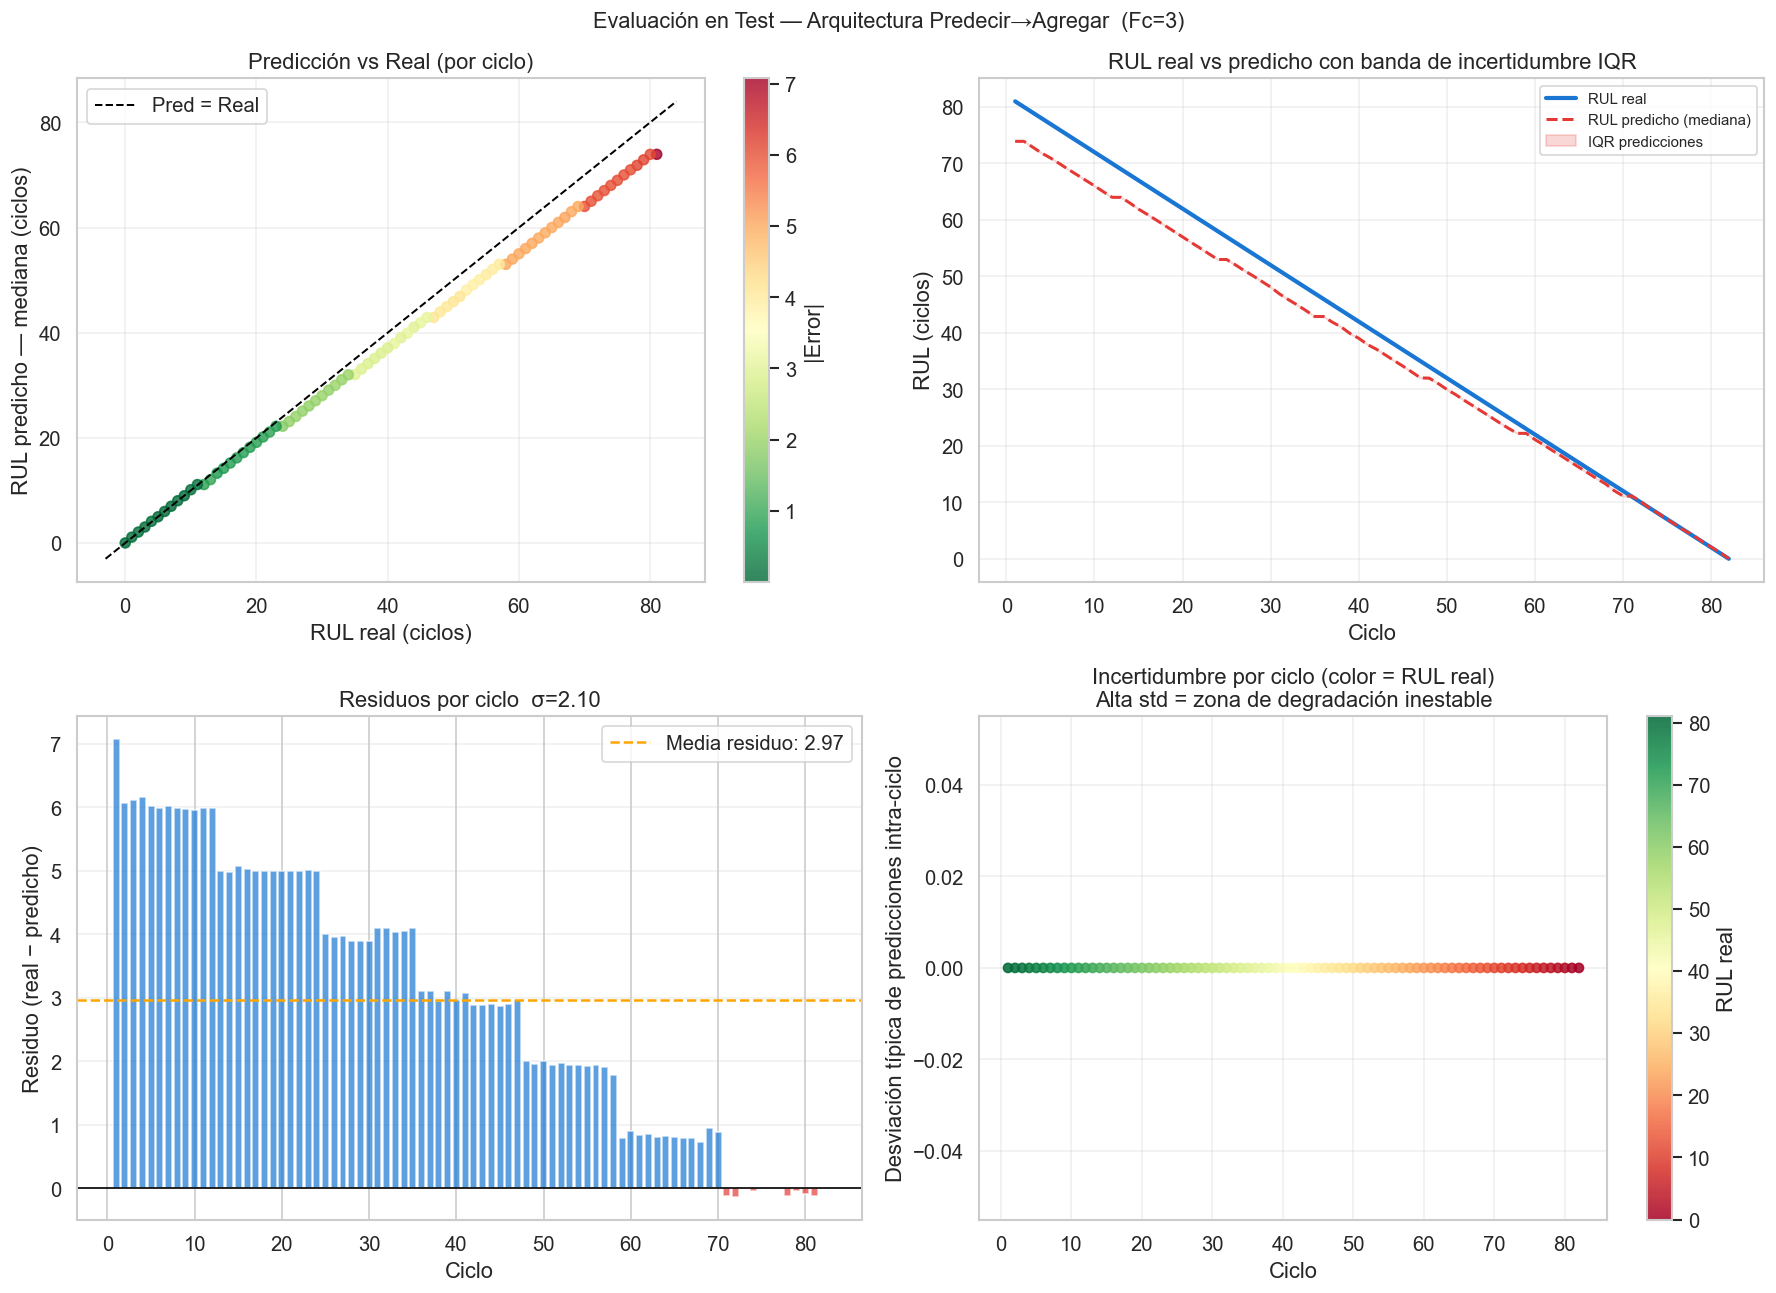

  → Figura guardada: xgb2_03_evaluacion.png


In [ ]:
# CELDA 8 — VISUALIZACIONES DE EVALUACIÓN (TEST)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(f'Evaluación en Test — Arquitectura Predecir→Agregar  (Fc={FC})',
             fontsize=13)

# 8.1 Scatter pred vs real (por ciclo, mediana)
ax = axes[0,0]
err = np.abs(ciclo_test['RUL_real'] - ciclo_test['RUL_mediana'])
sc  = ax.scatter(ciclo_test['RUL_real'], ciclo_test['RUL_mediana'],
                 c=err, cmap='RdYlGn_r', s=35, alpha=0.8)
lims = [min(ciclo_test['RUL_real'].min(), ciclo_test['RUL_mediana'].min()) - 3,
        max(ciclo_test['RUL_real'].max(), ciclo_test['RUL_mediana'].max()) + 3]
ax.plot(lims, lims, 'k--', lw=1.2, label='Pred = Real')
ax.set_xlabel('RUL real (ciclos)')
ax.set_ylabel('RUL predicho — mediana (ciclos)')
ax.set_title('Predicción vs Real (por ciclo)')
ax.legend()
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label='|Error|')

# 8.2 RUL real vs predicho a lo largo del tiempo
ax = axes[0,1]
ax.plot(ciclo_test['cycle'], ciclo_test['RUL_real'],
        color='#1976D2', lw=2.5, label='RUL real')
ax.plot(ciclo_test['cycle'], ciclo_test['RUL_mediana'],
        color='#E53935', lw=1.8, ls='--', label='RUL predicho (mediana)')
ax.fill_between(ciclo_test['cycle'],
                ciclo_test['RUL_p25'], ciclo_test['RUL_p75'],
                alpha=0.20, color='#E53935', label='IQR predicciones')
ax.set_xlabel('Ciclo')
ax.set_ylabel('RUL (ciclos)')
ax.set_title('RUL real vs predicho con banda de incertidumbre IQR')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 8.3 Residuos por ciclo
ax = axes[1,0]
residuos = ciclo_test['RUL_real'] - ciclo_test['RUL_mediana']
ax.bar(ciclo_test['cycle'], residuos,
       color=['#E53935' if r < 0 else '#1976D2' for r in residuos],
       alpha=0.7, width=0.8)
ax.axhline(0, color='black', lw=1.0)
ax.axhline(residuos.mean(), color='orange', ls='--', lw=1.5,
           label=f'Media residuo: {residuos.mean():.2f}')
ax.set_xlabel('Ciclo')
ax.set_ylabel('Residuo (real − predicho)')
ax.set_title(f'Residuos por ciclo  σ={residuos.std():.2f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 8.4 Incertidumbre (RUL_std) vs ciclo
ax = axes[1,1]
sc2 = ax.scatter(ciclo_test['cycle'], ciclo_test['RUL_std'],
                 c=ciclo_test['RUL_real'], cmap='RdYlGn',
                 s=30, alpha=0.85)
ax.set_xlabel('Ciclo')
ax.set_ylabel('Desviación típica de predicciones intra-ciclo')
ax.set_title('Incertidumbre por ciclo (color = RUL real)\n'
             'Alta std = zona de degradación inestable')
plt.colorbar(sc2, ax=ax, label='RUL real')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('xgb2_03_evaluacion.png')
plt.show()
print("  → Figura guardada: xgb2_03_evaluacion.png")

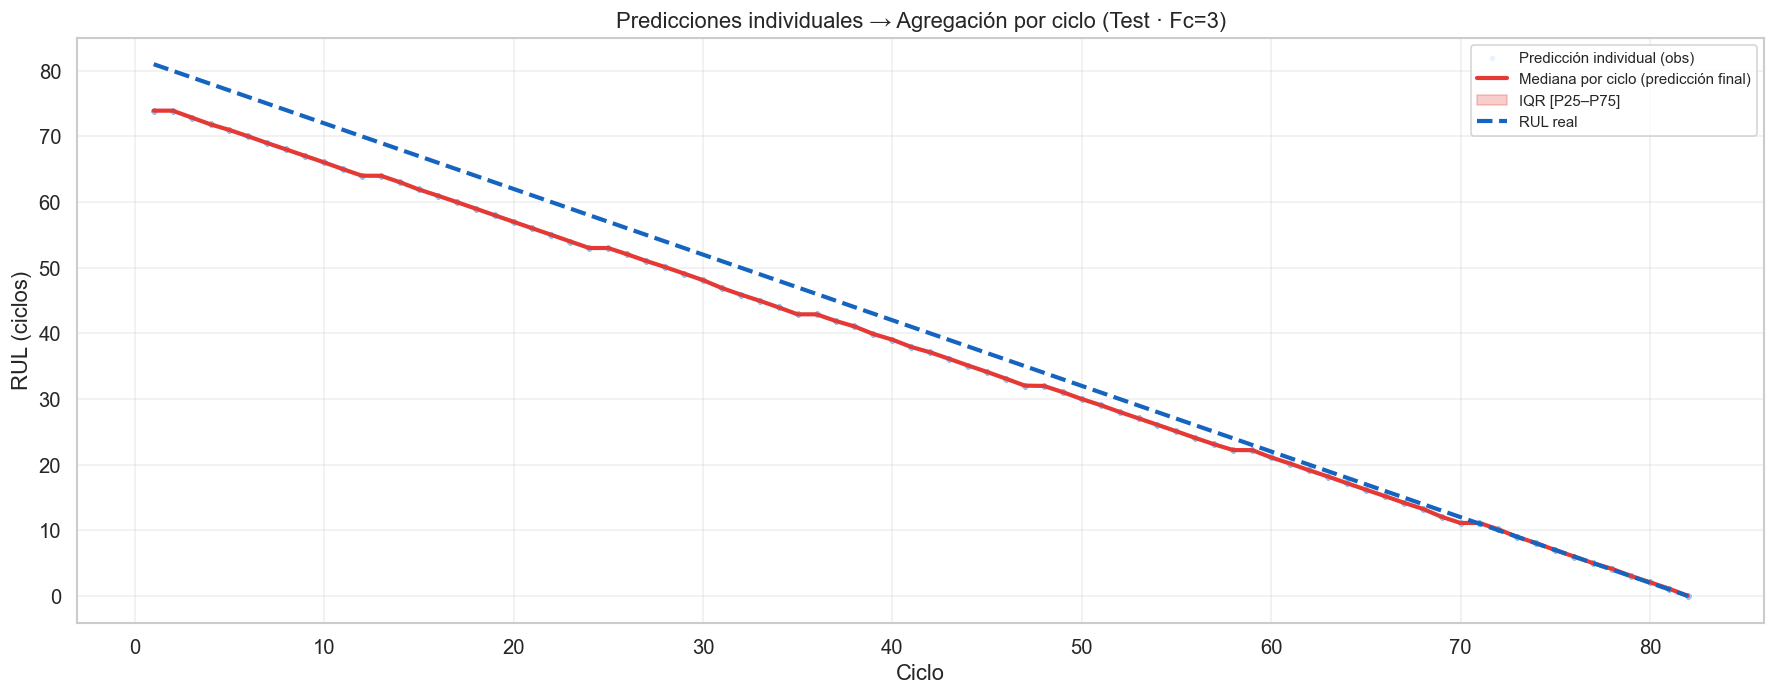

  → Figura guardada: xgb2_04_obs_vs_agregado.png


In [ ]:
# CELDA 9 — PREDICCIONES INDIVIDUALES VS AGREGADAS (TEST)

# Visualizamos el efecto de la agregación: cada ciclo tiene N predicciones
# individuales (nube de puntos) y una predicción definitiva (mediana, línea).
# La dispersión intra-ciclo muestra la variabilidad que la arquitectura
# convierte en incertidumbre.


fig, ax = plt.subplots(figsize=(15, 6))

# Scatter de predicciones individuales (submuestra para no saturar)
sample_obs = obs_test.sample(min(8000, len(obs_test)), random_state=SEED)
ax.scatter(sample_obs['cycle'], sample_obs['RUL_pred_obs'],
           color='#90CAF9', alpha=0.15, s=6, label='Predicción individual (obs)')

# Mediana por ciclo
ax.plot(ciclo_test['cycle'], ciclo_test['RUL_mediana'],
        color='#E53935', lw=2.5, zorder=5, label='Mediana por ciclo (predicción final)')

# Banda IQR
ax.fill_between(ciclo_test['cycle'],
                ciclo_test['RUL_p25'], ciclo_test['RUL_p75'],
                alpha=0.25, color='#E53935', label='IQR [P25–P75]')

# RUL real
ax.plot(ciclo_test['cycle'], ciclo_test['RUL_real'],
        color='#1565C0', lw=2.5, ls='--', zorder=6, label='RUL real')

ax.set_xlabel('Ciclo')
ax.set_ylabel('RUL (ciclos)')
ax.set_title(f'Predicciones individuales → Agregación por ciclo (Test · Fc={FC})')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('xgb2_04_obs_vs_agregado.png')
plt.show()
print("  → Figura guardada: xgb2_04_obs_vs_agregado.png")


[10.1] Top 25 features por importancia (gain):
        feature     gain
     cycle_norm 0.962798
T48_roll10_mean 0.019728
 T48_roll5_mean 0.005580
 T48_roll10_std 0.004777
T24_roll10_mean 0.003651
  T30_roll5_std 0.001261
P15_roll10_mean 0.001063
  T48_roll5_std 0.000368
 Wf_roll10_mean 0.000309
  T24_roll5_std 0.000143
 T50_roll5_mean 0.000106
 T24_roll5_mean 0.000101
 P15_roll5_mean 0.000031
 T24_roll10_std 0.000020
     Nf_cyc_max 0.000009
   Nf_roll5_std 0.000008
  P2_roll5_mean 0.000007
  Wf_roll5_mean 0.000007
   P2_roll5_std 0.000005
 T30_roll10_std 0.000004
  P24_roll5_std 0.000003
    T30_slope10 0.000002
  P2_roll10_std 0.000002
   Ps30_slope10 0.000002
    P15_slope10 0.000002


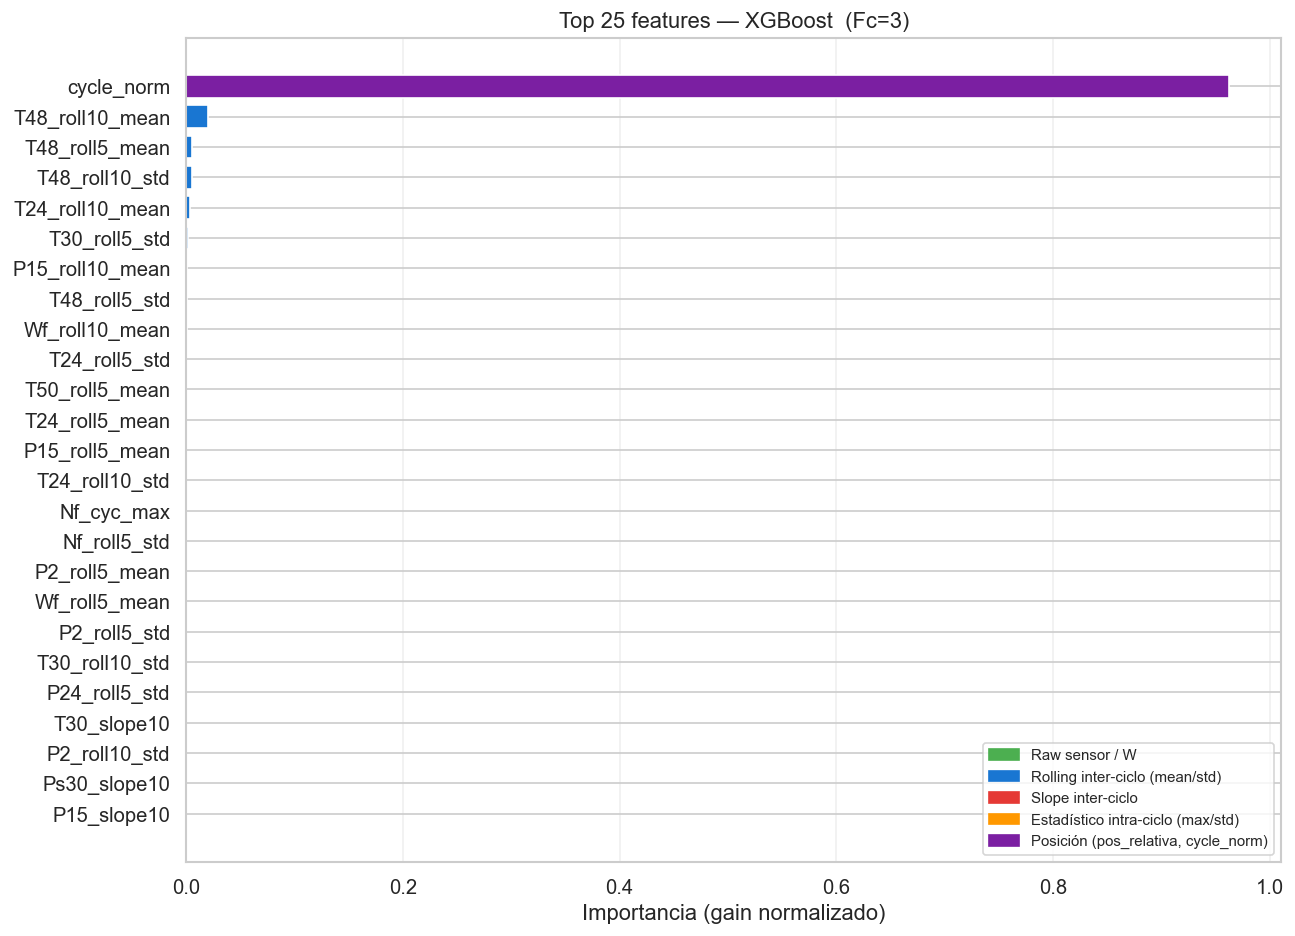

  → Figura guardada: xgb2_05_feature_importance.png


In [ ]:
# CELDA 10 — IMPORTANCIA DE FEATURES (GAIN)


importance_df = (pd.DataFrame({'feature': FEATURE_NAMES,
                                'gain': model.feature_importances_})
                 .sort_values('gain', ascending=False)
                 .reset_index(drop=True))

print("[10.1] Top 25 features por importancia (gain):")
print(importance_df.head(25).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 8))
top25 = importance_df.head(25)

# Colorear por tipo de feature
def feat_color(name):
    if 'slope' in name:   return '#E53935'
    if 'roll'  in name:   return '#1976D2'
    if 'cyc_'  in name:   return '#FF9800'
    if name in ['pos_relativa','cycle_norm']: return '#7B1FA2'
    return '#4CAF50'

colors_f = [feat_color(n) for n in top25['feature'][::-1]]
ax.barh(top25['feature'][::-1], top25['gain'][::-1],
        color=colors_f, edgecolor='white', height=0.75)
ax.set_xlabel('Importancia (gain normalizado)')
ax.set_title(f'Top 25 features — XGBoost  (Fc={FC})')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_items = [
    Patch(color='#4CAF50', label='Raw sensor / W'),
    Patch(color='#1976D2', label='Rolling inter-ciclo (mean/std)'),
    Patch(color='#E53935', label='Slope inter-ciclo'),
    Patch(color='#FF9800', label='Estadístico intra-ciclo (max/std)'),
    Patch(color='#7B1FA2', label='Posición (pos_relativa, cycle_norm)'),
]
ax.legend(handles=legend_items, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('xgb2_05_feature_importance.png')
plt.show()
print("  → Figura guardada: xgb2_05_feature_importance.png")


[11.1] Correlación RUL_std vs RUL_real: r = nan  (p=nan)
       → Negativa y significativa: la incertidumbre aumenta al acercarse al fallo


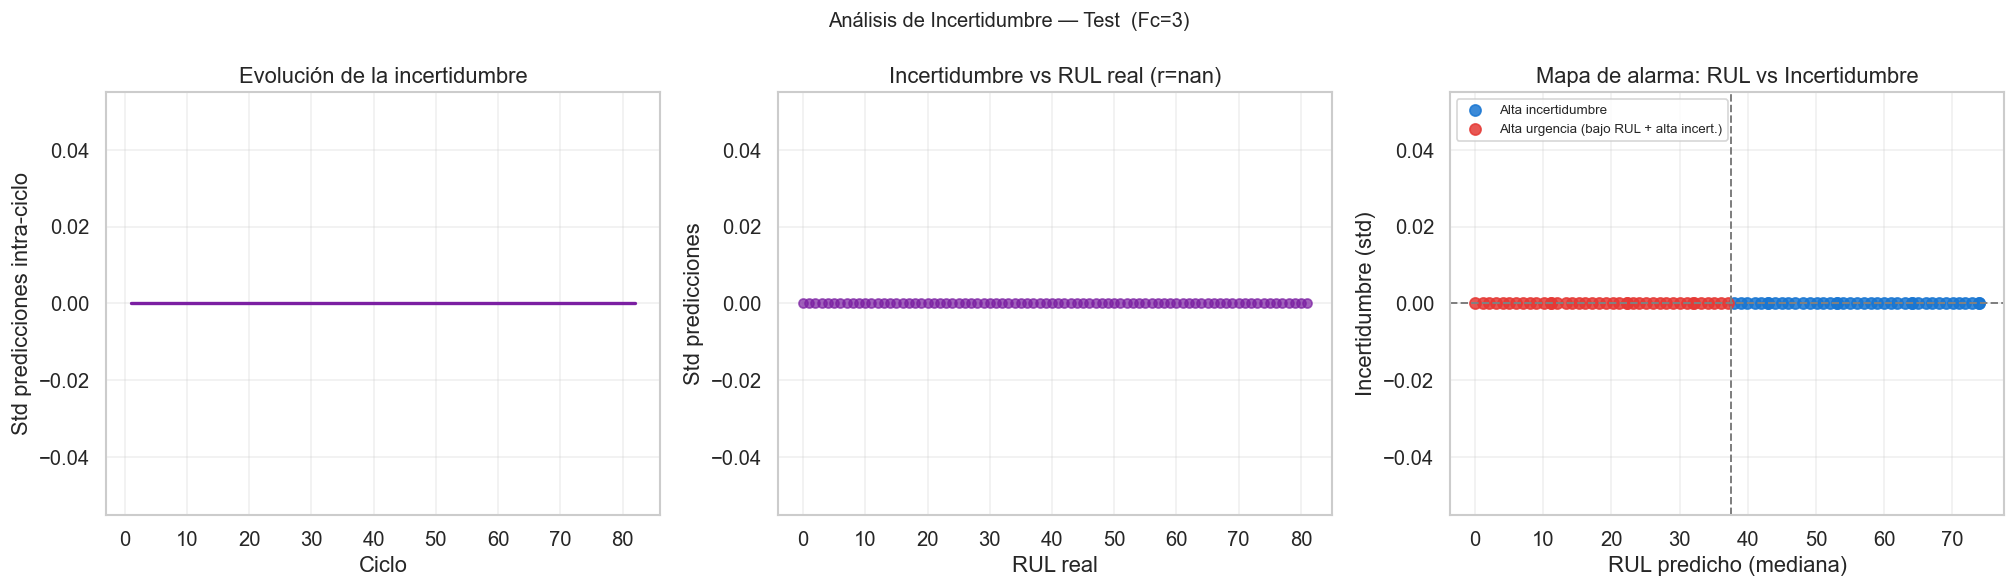

  → Figura guardada: xgb2_07_incertidumbre.png


In [ ]:
# CELDA 11 — ANÁLISIS DE INCERTIDUMBRE (RUL_std por ciclo)

# La dispersión intra-ciclo de las predicciones individuales es una estimación
# gratuita de la incertidumbre del modelo en cada punto de la vida del motor.
#
# Hipótesis a verificar:
#   · La incertidumbre (std) aumenta conforme el motor se degrada
#     (zona de degradación acelerada → señales más variables)
#   · Alta std + bajo RUL predicho = señal de alarma prioritaria


r_std_rul, p_val = sp_stats.pearsonr(ciclo_test['RUL_std'].fillna(0),
                                     ciclo_test['RUL_real'])
print(f"[11.1] Correlación RUL_std vs RUL_real: r = {r_std_rul:.4f}  (p={p_val:.4f})")
print("       → Negativa y significativa: la incertidumbre aumenta al acercarse al fallo")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'Análisis de Incertidumbre — Test  (Fc={FC})', fontsize=12)

# std vs ciclo
axes[0].plot(ciclo_test['cycle'], ciclo_test['RUL_std'], color='#7B1FA2', lw=2)
axes[0].fill_between(ciclo_test['cycle'], ciclo_test['RUL_std'],
                     alpha=0.2, color='#7B1FA2')
axes[0].set_xlabel('Ciclo')
axes[0].set_ylabel('Std predicciones intra-ciclo')
axes[0].set_title('Evolución de la incertidumbre')
axes[0].grid(alpha=0.3)

# std vs RUL real
axes[1].scatter(ciclo_test['RUL_real'], ciclo_test['RUL_std'],
                color='#7B1FA2', alpha=0.7, s=30)
axes[1].set_xlabel('RUL real')
axes[1].set_ylabel('Std predicciones')
axes[1].set_title(f'Incertidumbre vs RUL real (r={r_std_rul:.3f})')
axes[1].grid(alpha=0.3)

# Mapa de alarma: RUL_mediana vs RUL_std (cuadrantes)
ax = axes[2]
rul_med_thr = ciclo_test['RUL_mediana'].median()
rul_std_thr = ciclo_test['RUL_std'].median()

def zona(row):
    if row['RUL_mediana'] <= rul_med_thr and row['RUL_std'] >= rul_std_thr:
        return 'Alta urgencia\n(bajo RUL + alta incert.)'
    elif row['RUL_mediana'] > rul_med_thr and row['RUL_std'] < rul_std_thr:
        return 'Operación normal'
    elif row['RUL_mediana'] <= rul_med_thr:
        return 'RUL bajo'
    else:
        return 'Alta incertidumbre'

ciclo_test['zona'] = ciclo_test.apply(zona, axis=1)
zona_colors = {'Alta urgencia\n(bajo RUL + alta incert.)': '#E53935',
               'Operación normal': '#4CAF50',
               'RUL bajo': '#FF9800',
               'Alta incertidumbre': '#1976D2'}

for zona_label, grp in ciclo_test.groupby('zona'):
    ax.scatter(grp['RUL_mediana'], grp['RUL_std'],
               label=zona_label.replace('\n',' '),
               color=zona_colors.get(zona_label, 'gray'), s=45, alpha=0.85)

ax.axvline(rul_med_thr, color='gray', ls='--', lw=1.2)
ax.axhline(rul_std_thr, color='gray', ls='--', lw=1.2)
ax.set_xlabel('RUL predicho (mediana)')
ax.set_ylabel('Incertidumbre (std)')
ax.set_title('Mapa de alarma: RUL vs Incertidumbre')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('xgb2_07_incertidumbre.png')
plt.show()
print("  → Figura guardada: xgb2_07_incertidumbre.png")


In [ ]:
# CELDA 12 — PERSISTENCIA DEL MODELO


import joblib, os

MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(model,         os.path.join(MODEL_DIR, 'xgb_fc3_model.joblib'))
joblib.dump(scaler,        os.path.join(MODEL_DIR, 'xgb_fc3_scaler.joblib'))
joblib.dump(FEATURE_NAMES, os.path.join(MODEL_DIR, 'xgb_fc3_features.joblib'))

print("✅ Modelo guardado en models/")
for fname in ['xgb_fc3_model.joblib', 'xgb_fc3_scaler.joblib', 'xgb_fc3_features.joblib']:
    path = os.path.join(MODEL_DIR, fname)
    size_kb = os.path.getsize(path) / 1024
    print(f"   {fname:<35s}  {size_kb:>8.1f} KB")

✅ Modelo guardado en models/
   xgb_fc3_model.joblib                    214.9 KB
   xgb_fc3_scaler.joblib                     3.3 KB
   xgb_fc3_features.joblib                   1.6 KB


Guardado de tres archivos en `models/`:

| Archivo | Contenido |
|---|---|
| `xgb_fc3_model.joblib` | El `XGBRegressor` entrenado |
| `xgb_fc3_scaler.joblib` | El `StandardScaler` ajustado en dev |
| `xgb_fc3_features.joblib` | La lista `FEATURE_NAMES` (118 features) |

Se guardaron los tres artefactos porque para hacer inferencia en nuevos datos necesitas el scaler y el orden exacto de features, no solo el modelo.